<a href="https://colab.research.google.com/github/CrstinLeo/github_learning/blob/main/traffic_cv_mvp_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 交通拥堵检测 MVP —— YOLO 车辆计数 + 拥堵评估

最小可行项目，按顺序运行下面每个 Cell：

1. 安装依赖
2. 准备测试图片（自动下载示例图 / 也可以自己上传）
3. 加载 YOLO 模型
4. 车辆检测函数
5. 拥堵等级判断函数
6. 跑全流程 + 可视化标注结果
7. 汇总图表（各张图片车辆数对比）

每个 Cell 上面都有简短说明，建议**一格一格运行**，看清楚每一步的输出再往下走。


## 1. 安装依赖
（Colab 第一次运行大概需要 20-40 秒）

In [1]:
!pip install -q ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.4 MB/s eta 0:00:00


## 2. 配置参数

把所有"可调的东西"放在一个 dict 里，方便你之后改阈值时一眼就能找到。

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

CONFIG = {
    "model_name": "yolov8n.pt",       # 最小最快的YOLOv8模型
    "confidence_threshold": 0.35,
    # COCO数据集里车辆相关类别: 2=car, 3=motorcycle, 5=bus, 7=truck
    "vehicle_class_ids": {2, 3, 5, 7},
    "vehicle_class_names": {2: "car", 3: "motorcycle", 5: "bus", 7: "truck"},
    # 拥堵等级阈值（最简化版本：按检测到的车辆数量分档）
    "congestion_thresholds": {"low": 5, "medium": 15},
    "image_dir": "/content/traffic_images",
}

os.makedirs(CONFIG["image_dir"], exist_ok=True)
print("配置加载完成:", CONFIG)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
配置加载完成: {'model_name': 'yolov8n.pt', 'confidence_threshold': 0.35, 'vehicle_class_ids': {2, 3, 5, 7}, 'vehicle_class_names': {2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}, 'congestion_thresholds': {'low': 5, 'medium': 15}, 'image_dir': '/content/traffic_images'}


## 3. 准备测试图片

两种方式选一种：

- **方式A（默认）**：自动下载几张维基共享资源（Wikimedia Commons）的真实交通拥堵照片，免费可商用授权。
- **方式B**：如果你想用自己的图片，运行下面的 `files.upload()` 那个 Cell，选择本地图片上传即可（会自动放进同一个文件夹）。


In [3]:
import urllib.request

# 几张真实交通拥堵照片（Wikimedia Commons，CC授权），用 Special:FilePath 拿到稳定直链
SAMPLE_URLS = {
    "miami_i95.jpg": "https://commons.wikimedia.org/wiki/Special:FilePath/Miami_traffic_jam,_I-95_North_rush_hour.jpg",
    "highway_401.jpg": "https://commons.wikimedia.org/wiki/Special:FilePath/401_Traffic_Jam.jpg",
    "la_traffic.jpg": "https://commons.wikimedia.org/wiki/Special:FilePath/LA_traffic_jam_%3D_daily_occurrence_!.jpg",
}

headers = {"User-Agent": "Mozilla/5.0 (traffic-cv-mvp learning project)"}

for filename, url in SAMPLE_URLS.items():
    dest = os.path.join(CONFIG["image_dir"], filename)
    try:
        req = urllib.request.Request(url, headers=headers)
        with urllib.request.urlopen(req, timeout=15) as resp, open(dest, "wb") as f:
            f.write(resp.read())
        print(f"下载成功: {filename}")
    except Exception as e:
        print(f"下载失败 {filename}: {e}（可以跳过，用方式B自己上传图片）")


下载成功: miami_i95.jpg
下载成功: highway_401.jpg
下载失败 la_traffic.jpg: HTTP Error 429: Too many requests (f061ab2)（可以跳过，用方式B自己上传图片）


**方式B：自己上传图片（可选，跳过也没关系）**

如果上面自动下载的图不够用，或者你想测试自己的图片，运行下面这格，选择文件上传。

In [4]:
from google.colab import files

uploaded = files.upload()
for filename in uploaded.keys():
    dest = os.path.join(CONFIG["image_dir"], filename)
    with open(dest, "wb") as f:
        f.write(uploaded[filename])
    print(f"已保存: {dest}")


In [5]:
image_paths = [
    os.path.join(CONFIG["image_dir"], f)
    for f in sorted(os.listdir(CONFIG["image_dir"]))
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]
print(f"共找到 {len(image_paths)} 张图片:")
for p in image_paths:
    print(" -", p)


共找到 2 张图片:
 - /content/traffic_images/highway_401.jpg
 - /content/traffic_images/miami_i95.jpg


## 4. 加载 YOLO 模型

第一次运行会自动下载预训练权重（约6MB）。

In [6]:
model = YOLO(CONFIG["model_name"])
print("模型加载完成")


模型加载完成


## 5. 车辆检测函数

只负责一件事：输入图片路径，输出"检测到的车辆框列表"。


In [7]:
def detect_vehicles(image_path, model, config):
    """
    对单张图片做YOLO推理，只保留车辆类别的检测结果。

    返回: list of dict，每个dict包含 class_name, confidence, box(x1,y1,x2,y2)
    """
    results = model(image_path, conf=config["confidence_threshold"], verbose=False)

    detections = []
    for result in results:
        for box in result.boxes:
            class_id = int(box.cls[0])
            if class_id not in config["vehicle_class_ids"]:
                continue
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            detections.append({
                "class_name": config["vehicle_class_names"][class_id],
                "confidence": float(box.conf[0]),
                "box": (x1, y1, x2, y2),
            })
    return detections


## 6. 拥堵等级判断函数

只负责一件事：把"车辆数量"转成"拥堵等级"。
感知（看见什么）和决策（怎么判断）分开写，是CV项目里很重要的设计习惯。

In [8]:
def classify_congestion(vehicle_count, config):
    thresholds = config["congestion_thresholds"]
    if vehicle_count <= thresholds["low"]:
        return "low"
    elif vehicle_count <= thresholds["medium"]:
        return "medium"
    else:
        return "high"


LEVEL_COLOR = {  # BGR for cv2.rectangle / RGB会在画图时再转换
    "low": (0, 200, 0),
    "medium": (0, 165, 255),
    "high": (0, 0, 255),
}


## 7. 跑全流程 + 可视化

依次对每张图片：检测 → 统计 → 判断拥堵等级 → 画框 → 用 matplotlib 显示出来。

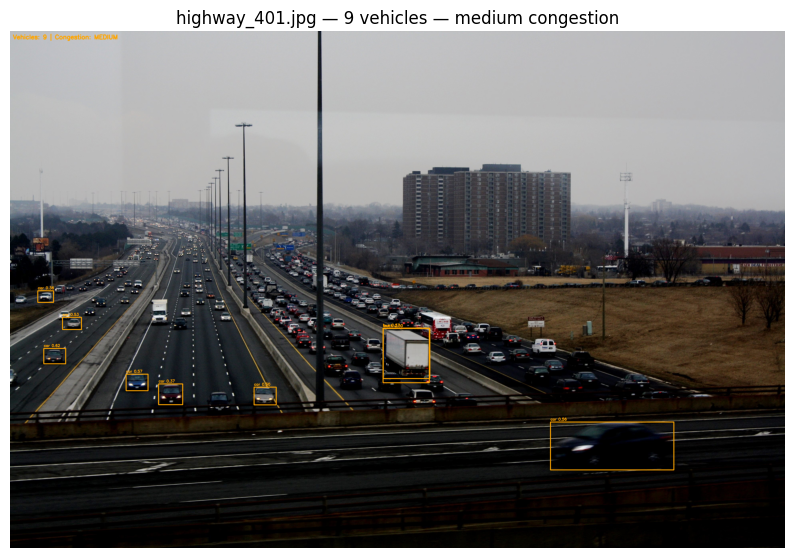

[highway_401.jpg] 车辆总数=9  类别分布={'car': 7, 'truck': 1, 'bus': 1}  拥堵等级=medium



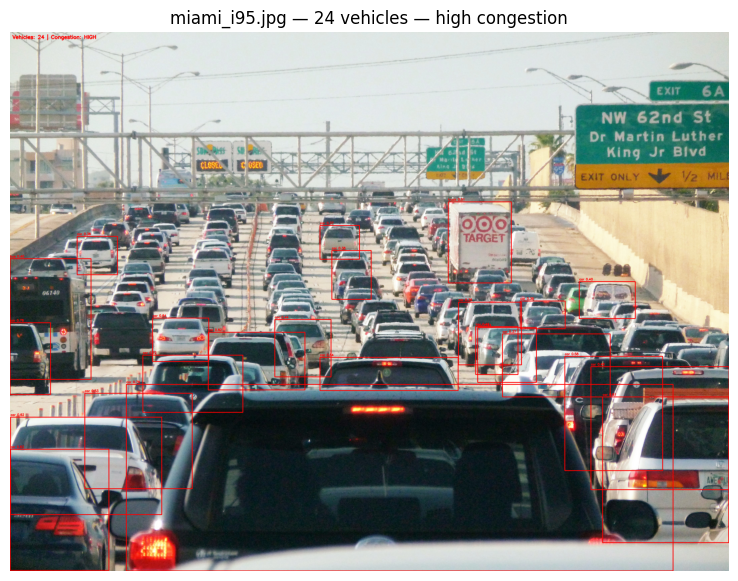

[miami_i95.jpg] 车辆总数=24  类别分布={'car': 22, 'truck': 1, 'bus': 1}  拥堵等级=high



In [9]:
all_reports = []  # 收集每张图的结果，最后做汇总图表

for image_path in image_paths:
    detections = detect_vehicles(image_path, model, CONFIG)
    total = len(detections)

    breakdown = {}
    for det in detections:
        breakdown[det["class_name"]] = breakdown.get(det["class_name"], 0) + 1

    level = classify_congestion(total, CONFIG)
    color = LEVEL_COLOR[level]

    image = cv2.imread(image_path)
    for det in detections:
        x1, y1, x2, y2 = map(int, det["box"])
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 3)
        label = f'{det["class_name"]} {det["confidence"]:.2f}'
        cv2.putText(image, label, (x1, max(y1 - 8, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    summary = f"Vehicles: {total} | Congestion: {level.upper()}"
    cv2.putText(image, summary, (15, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 3)

    # cv2读图是BGR，matplotlib显示要转成RGB，不然颜色会反
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 7))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title(f"{os.path.basename(image_path)} — {total} vehicles — {level} congestion")
    plt.show()

    print(f"[{os.path.basename(image_path)}] 车辆总数={total}  类别分布={breakdown}  拥堵等级={level}\n")

    all_reports.append({
        "image": os.path.basename(image_path),
        "total_vehicles": total,
        "breakdown": breakdown,
        "level": level,
    })


## 8. 汇总图表

把所有图片的检测结果放一起对比，这是"用数据说话"的部分——单张图片的结果是个例，
汇总后才能看出"哪张图更拥堵"，这也是后续接入真实交通监控系统时的基本思路。

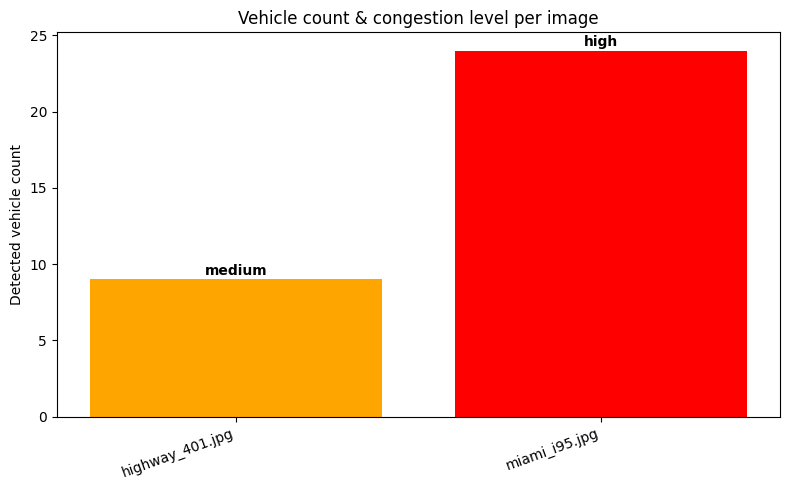

In [10]:
import matplotlib.pyplot as plt

names = [r["image"] for r in all_reports]
counts = [r["total_vehicles"] for r in all_reports]
colors = [
    {"low": "green", "medium": "orange", "high": "red"}[r["level"]]
    for r in all_reports
]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, counts, color=colors)
plt.ylabel("Detected vehicle count")
plt.title("Vehicle count & congestion level per image")
plt.xticks(rotation=20, ha="right")

for bar, r in zip(bars, all_reports):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
              r["level"], ha="center", fontweight="bold")

plt.tight_layout()
plt.show()


## 下一步可以怎么练（不需要现在做，留个方向）

1. 把"车辆数量阈值"换成"车辆密度"（车辆数 / 图片面积），更贴近真实交通工程指标。
2. 给图片画一个 ROI（感兴趣区域，比如只统计某条车道），只统计框在ROI内的车辆。
3. 把单图换成视频，引入追踪算法（YOLO + ByteTrack），统计车流量而不是单帧计数。
4. 把 `CONFIG` 改成读取本地 `config.json` 文件，练习"配置与代码分离"的工程习惯。
